In [1]:
import numpy as np
from numpy import ndarray, int64
import torch

Firstly, we import the data from the data folder. For the task 1 we only want the first question, so we only take the labels of the first question. 

In [2]:
import os
from pathlib import Path
from galaxyzoo.data import load_data

img_path = Path("data/images")
labels_path = Path("data/labels.csv")

# Load the data
image_paths, labels_class = load_data(img_path, labels_path, task="task1")

## Preprocessing
We will split the data into train, validation and test sets. 

In [3]:
from sklearn.model_selection import train_test_split

train_images, temp_images, train_labels, temp_labels = train_test_split(
    image_paths,
    labels_class,
    test_size=0.3,
    random_state=42,
    stratify=labels_class   # split to mantain the imbalance
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f'Training size: {len(train_labels)} ({len(train_labels)/len(labels_class)*100:.0f}%)')
print(f'Validation size: {len(val_labels)} ({len(val_labels)/len(labels_class)*100:.0f}%)')
print(f'Test size: {len(test_labels)} ({len(test_labels)/len(labels_class)*100:.0f}%)')

Training size: 43104 (70%)
Validation size: 9237 (15%)
Test size: 9237 (15%)


Next, we have to create a dataset for each set. We will use a different transformation for the training set, to increase the performance. 

In [4]:
from torchvision import transforms
from galaxyzoo.data import GalaxiesDataset
from torch.utils.data import DataLoader
import torch

dim_pixels = 96

# Compute mean and std on the training set, needed for Normalize
stats_transform = transforms.Compose([
    transforms.CenterCrop(220),
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.ToTensor(),
])
stats_dataset = GalaxiesDataset(train_images, train_labels, transform=stats_transform)
stats_loader = DataLoader(stats_dataset, batch_size=256, shuffle=False)

mean = torch.zeros(3)
std = torch.zeros(3)
for imgs, _ in stats_loader:
    mean += imgs.mean(dim=[0, 2, 3])
    std += imgs.std(dim=[0, 2, 3])
mean /= len(stats_loader)
std /= len(stats_loader)

print(f"Mean: {mean.tolist()}")
print(f"Std:  {std.tolist()}")

Mean: [0.09521738439798355, 0.08255618065595627, 0.06455562263727188]
Std:  [0.13912498950958252, 0.11660976707935333, 0.10072098672389984]


In [5]:
train_transform = transforms.Compose([
    transforms.CenterCrop(220),
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
])

validation_test_transform = transforms.Compose([
    transforms.CenterCrop(220),
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
])

train_dataset = GalaxiesDataset(train_images, train_labels, transform=train_transform)
validation_dataset = GalaxiesDataset(val_images, val_labels, transform=validation_test_transform)
test_dataset = GalaxiesDataset(test_images, test_labels, transform=validation_test_transform)

As the answers are imbalanced we have to use weights for training the model. 

In [6]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_labels)

# Add weights as the data are imbalanced
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_labels
)

weights = torch.tensor(weights, dtype=torch.float32)

We plot the counts of every answer and also they weighted answer to validate the weights used. 

Text(0.5, 1.0, 'Answers classification weighted')

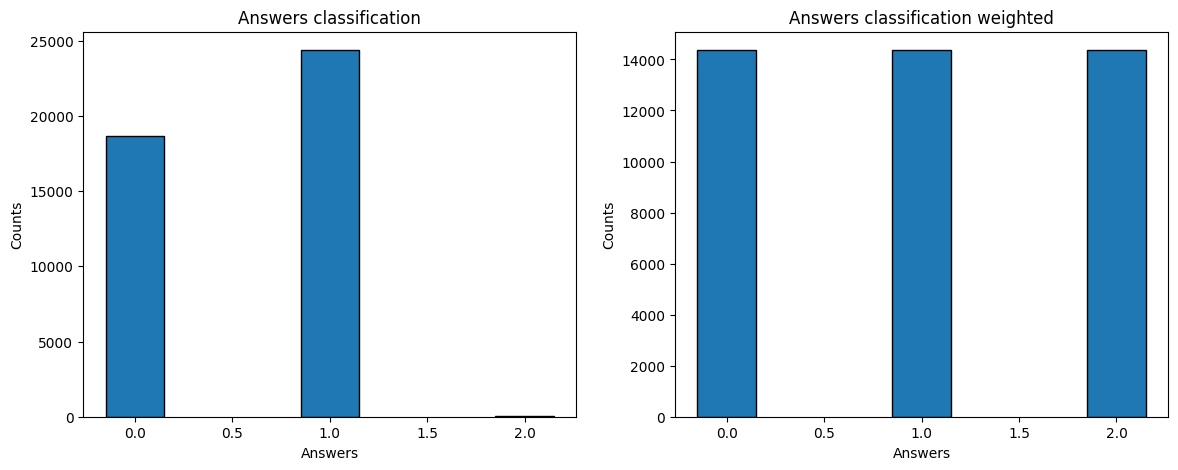

In [7]:
import matplotlib.pyplot as plt

labels_tensor = torch.tensor(train_labels)
counts = torch.bincount(labels_tensor)

# Plot the figure
fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(14)

ax1 = plt.subplot(1,2,1)
ax1.bar([0,1,2], counts, width=0.3, edgecolor='k')
ax1.set_xlabel("Answers")
ax1.set_ylabel("Counts")
ax1.set_title('Answers classification')

ax2 = plt.subplot(1,2,2)
ax2.bar([0,1,2], counts*weights, width=0.3, edgecolor='k')
ax2.set_xlabel("Answers")
ax2.set_ylabel("Counts")
ax2.set_title('Answers classification weighted')

The weights are balancing the data, just what we want. 

Next, we will transform the dataset to dataloader of training, validation and test data. 

In [8]:
from torch.utils.data import DataLoader

batch_size=64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Training and fitting
After the preprocessing, we just need to specify the parameters of the model and fit the data. 

In [9]:
from torch import nn
from torch.optim import AdamW
from galaxyzoo.cnn import CNN
from galaxyzoo.training_utils import fit
from torch.optim.lr_scheduler import ReduceLROnPlateau

in_channels = 3     # RGB
out_channels = 3    # 1 channel per answer (3 answers)

cnn_model = CNN(
    in_channels=in_channels,
    out_channels=out_channels,
    input_shape=(dim_pixels, dim_pixels),
    hidden_channels=16,
    final_hidden_channels=64,
    activation="relu",
)

cnn_optimizer = AdamW(cnn_model.parameters(), lr=5e-4, weight_decay=1e-4)
loss_function = nn.CrossEntropyLoss(weight=weights)
epochs = 10

scheduler = ReduceLROnPlateau(
    cnn_optimizer,
    mode='min',
    factor=0.5,
    patience=2,
)

train_losses, val_losses, train_accuracies, val_accuracies = fit(
    epochs=epochs,
    loss_function=loss_function,
    model=cnn_model,
    optimizer=cnn_optimizer,
    train_loader=train_loader,
    validation_loader=validation_loader,
    include_accuracy=True,
    scheduler=scheduler,
    task="classification"
)

-------------------------------
| Epoch 1                     |
| Train loss: 0.6194          |
| Validation loss: 0.6085     |
| Train accuracy: 74.55%      |
| Validation accuracy: 73.55% |
| Learning rate: 5.00e-04     |
-------------------------------
-------------------------------
| Epoch 2                     |
| Train loss: 0.5683          |
| Validation loss: 0.6704     |
| Train accuracy: 76.19%      |
| Validation accuracy: 65.22% |
| Learning rate: 5.00e-04     |
-------------------------------
-------------------------------
| Epoch 3                     |
| Train loss: 0.5537          |
| Validation loss: 0.5174     |
| Train accuracy: 76.75%      |
| Validation accuracy: 76.72% |
| Learning rate: 5.00e-04     |
-------------------------------
-------------------------------
| Epoch 4                     |
| Train loss: 0.5061          |
| Validation loss: 0.5162     |
| Train accuracy: 77.92%      |
| Validation accuracy: 76.68% |
| Learning rate: 5.00e-04     |
--------

It is more useful to see the loss and the accuracy in a plot. 

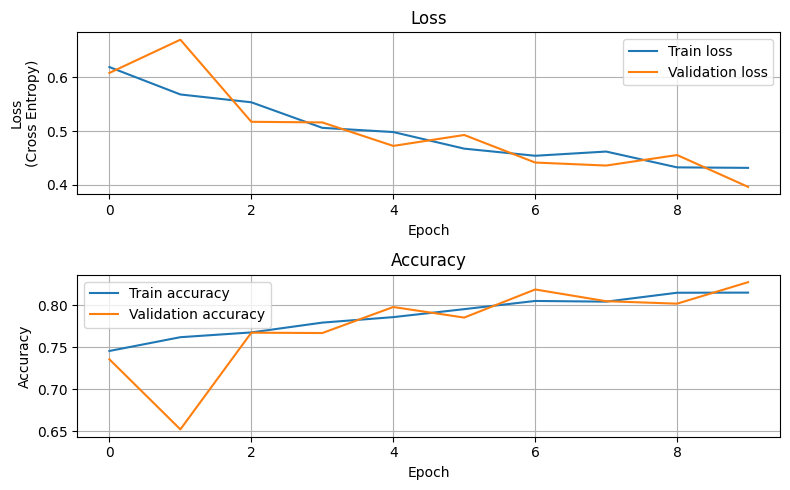

In [10]:
# Plot the figure
fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(8)

ax1 = plt.subplot(2,1,1)
ax1.plot(train_losses, label="Train loss")
ax1.plot(val_losses, label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss\n(Cross Entropy)")
ax1.set_title("Loss")
ax1.legend()
ax1.grid()

ax2 = plt.subplot(2,1,2)
ax2.plot(train_accuracies, label="Train accuracy")
ax2.plot(val_accuracies, label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid()

plt.tight_layout()

## Evaluation
Finally, we will evaluate the model with the test data. We will compute the confusion matrix and the ROC curves. 

In [11]:
import torch.nn.functional as F

labels_test = []
labels_preds = []
labels_probs = []

with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = cnn_model(imgs)
        preds = torch.argmax(outputs, dim=1)
        probs = F.softmax(outputs, dim=1)

        labels_test.extend(labels.cpu().numpy())
        labels_preds.extend(preds.cpu().numpy())
        labels_probs.extend(probs.cpu().numpy())

### Confusion matrix

Text(0.5, 1.0, 'Confusion Matrix')

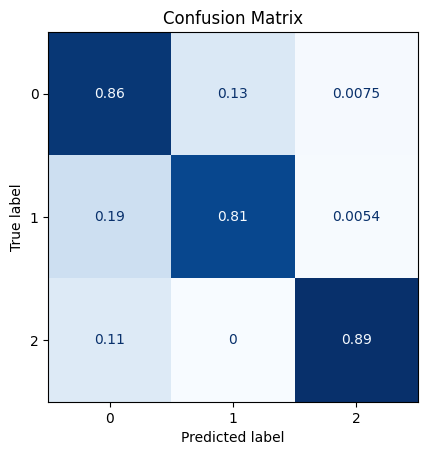

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(labels_test, labels_preds, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])

disp.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")

### ROC curves

Text(0.5, 1.0, 'ROC curves')

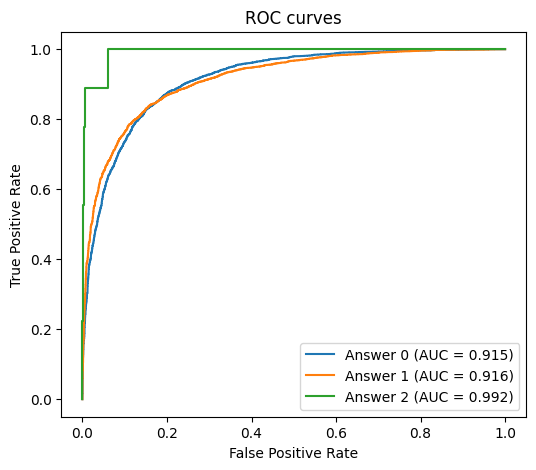

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

labels_test_bin = label_binarize(labels_test, classes=[0,1,2])
labels_probs = np.array(labels_probs)

# Plot the figure
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(6)

for i in range(3):
    fpr, tpr, _ = roc_curve(labels_test_bin[:, i], labels_probs[:, i])
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label=f"Answer {i} (AUC = {roc_auc:.3f})")

ax.legend()
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves")

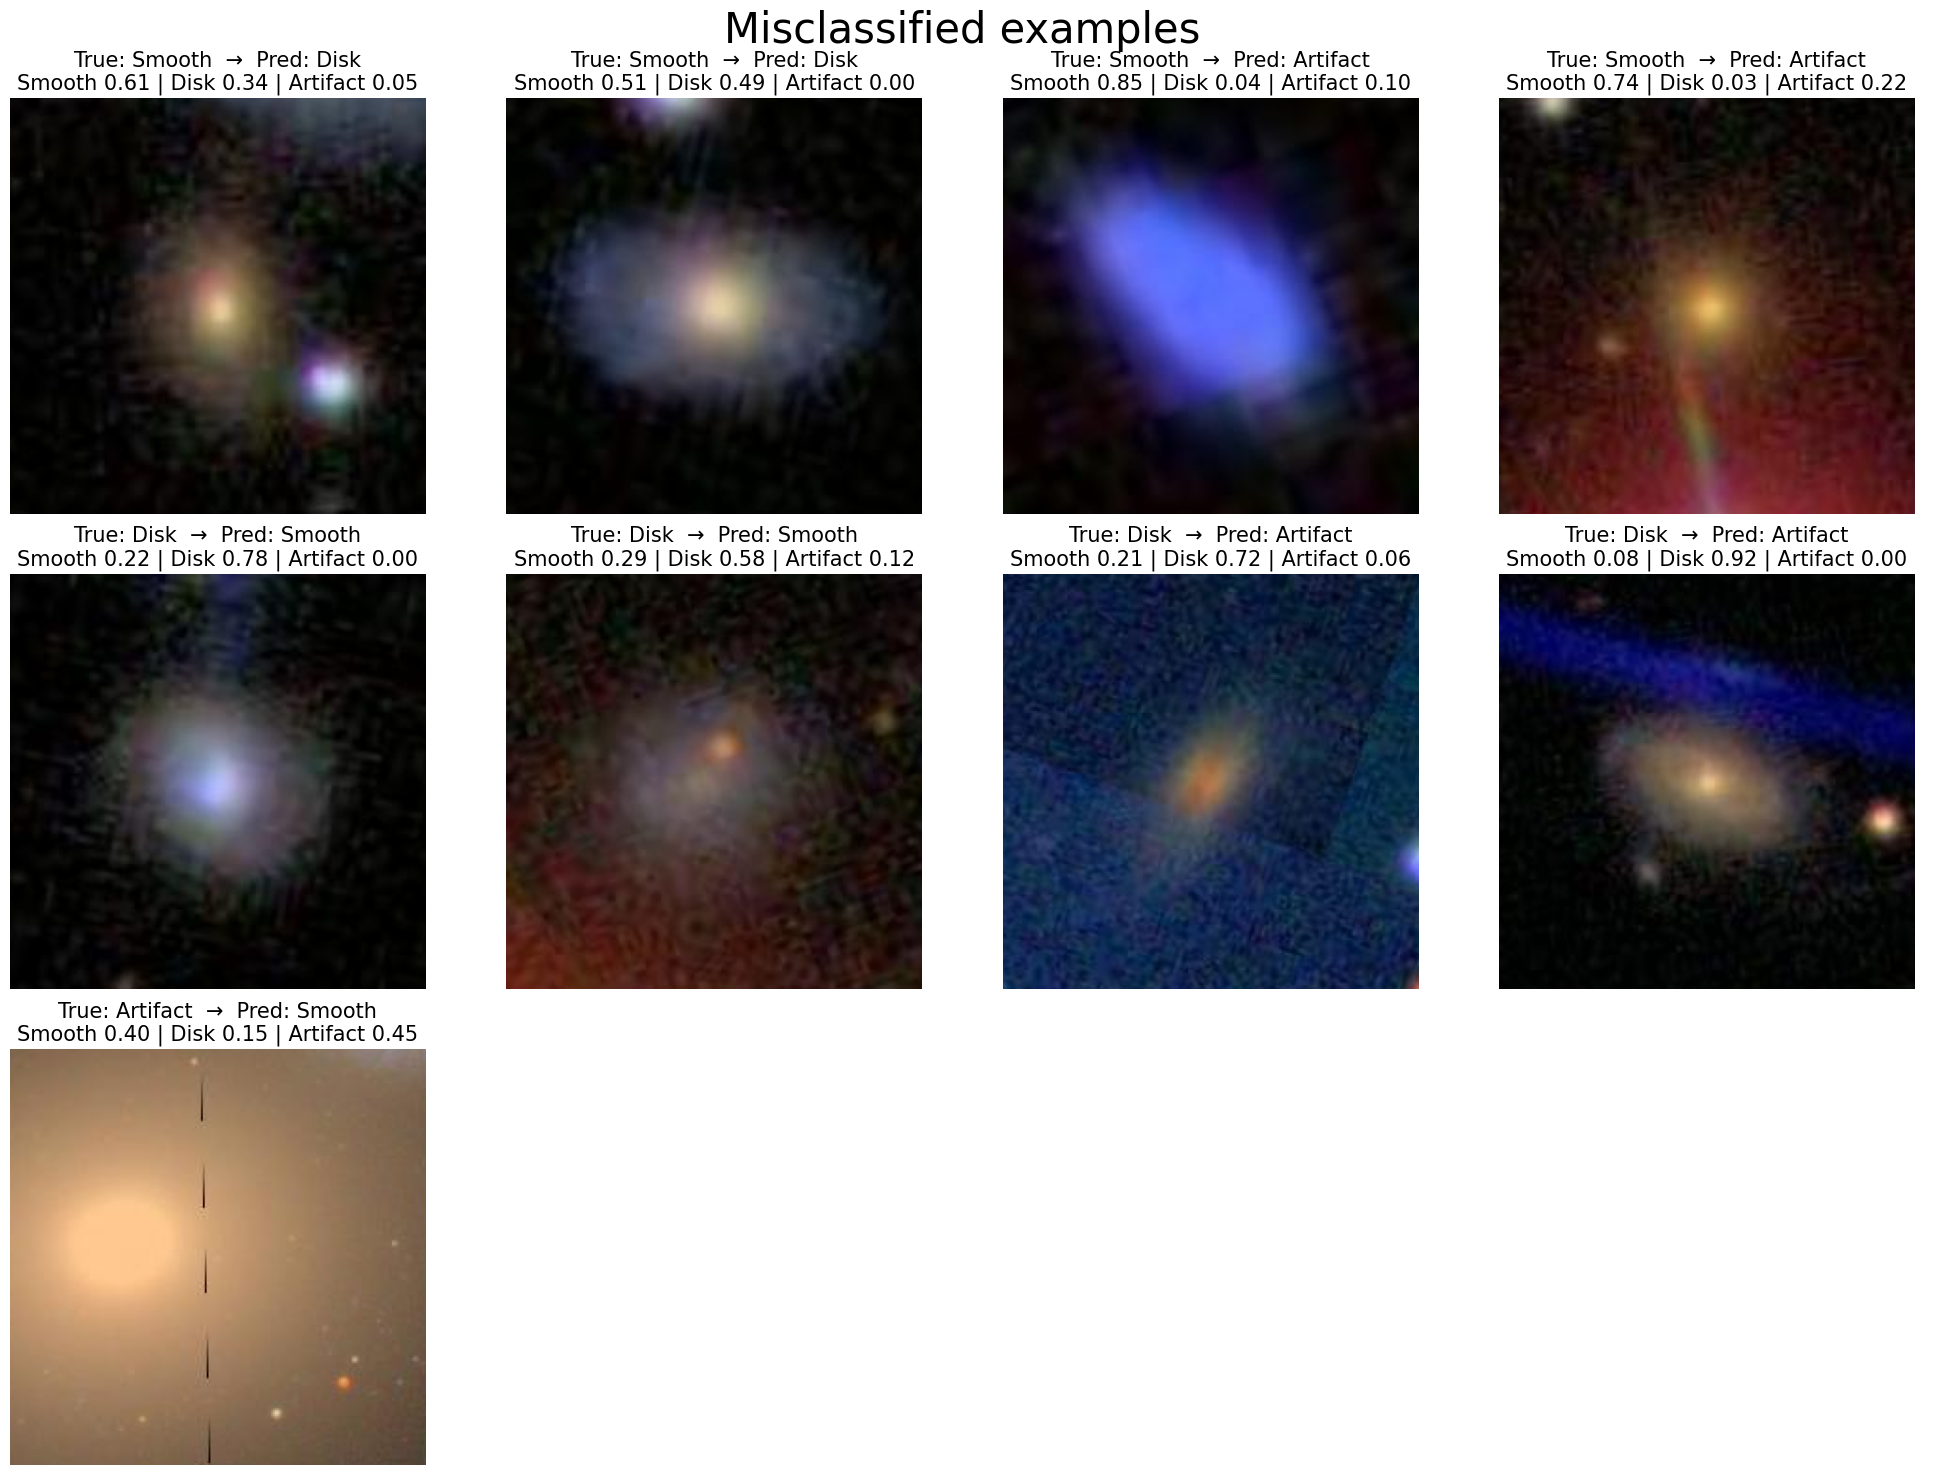

In [ ]:
import pandas as pd
import random
from PIL import Image

random.seed(42)
class_names = {0: "Smooth", 1: "Disk", 2: "Artifact"}

# Load original vote fractions
raw_labels = pd.read_csv(labels_path).set_index('GalaxyID')

# Find misclassified indices
labels_test_arr = np.array(labels_test)
labels_preds_arr = np.array(labels_preds)
misclassified_idx = np.where(labels_test_arr != labels_preds_arr)[0]

# Group by error type (true_class → predicted_class)
error_types = {}
for idx in misclassified_idx:
    key = (int(labels_test_arr[idx]), int(labels_preds_arr[idx]))
    error_types.setdefault(key, []).append(idx)

# Add 2 samples per error type
samples = []
for (true_cls, pred_cls), indices in sorted(error_types.items()):
    for idx in random.sample(list(indices), min(2, len(indices))):
        samples.append((idx, true_cls, pred_cls))

# Plot the figure
n_cols = 4
n_rows = -(-len(samples) // n_cols)  # ceiling division
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
axs = axs.flatten()

for plot_idx, (idx, true_cls, pred_cls) in enumerate(samples):
    img_path = test_images[idx]
    galaxy_id = int(os.path.basename(img_path).replace('.jpg', ''))

    v1 = raw_labels.loc[galaxy_id, 'Class1.1']
    v2 = raw_labels.loc[galaxy_id, 'Class1.2']
    v3 = raw_labels.loc[galaxy_id, 'Class1.3']

    img = transforms.CenterCrop(220)(Image.open(img_path).convert("RGB"))
    axs[plot_idx].imshow(img)
    axs[plot_idx].set_title(
        f"True: {class_names[true_cls]}  →  Pred: {class_names[pred_cls]}\n"
        f"Smooth {v1:.2f} | Disk {v2:.2f} | Artifact {v3:.2f}",
        fontsize=15
    )
    axs[plot_idx].axis('off')

for i in range(len(samples), len(axs)):
    axs[i].axis('off')

plt.suptitle("Misclassified examples", fontsize=30)
plt.tight_layout()
plt.show()